# 实验三：生成对抗网络 GAN 与 DCGAN 图像生成

本笔记本对应《深度学习实验任务书3：生成对抗网络 GAN 及 DCGAN 实验》。第一版先按任务书主线完成 **MNIST 手写数字生成**：

- 使用 `torchvision.datasets.MNIST` 加载数据；
- 按任务书补全 `DCGAN_Discriminator` 与 `DCGAN_Generator`；
- 使用 `BCELoss + Adam` 训练生成器与判别器；
- 可视化训练损失与生成结果；
- 附带 `BIGGAN` 的原理分析、预训练推理入口与对比框架，便于后续完成扩展实验。

说明：本 notebook 参照 `exp1/exp2` 的结构组织，优先保证**可运行、便于写实验报告、后续易扩展**。

## 1. 环境与依赖

建议在 `exp/exp3/` 目录中使用 Jupyter 打开本笔记本。若本机未安装 PyTorch / torchvision，可先执行：

```bash
pip install torch torchvision matplotlib numpy pillow
```

若计划尝试扩展实验中的 `BIGGAN` 预训练推理，可额外安装：

```bash
pip install pytorch-pretrained-biggan
```

In [1]:
import math
import random
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

device: cuda
torch: 2.10.0+cu128
torchvision: 0.25.0+cu128


## 2. 加载 MNIST 数据集

任务书中给出了 `load_dataset(batch_size=10, download=True)` 的基本写法，这里保留相同思路，并做两点小补充：

- 归一化为 `[-1, 1]`，与生成器输出层 `Tanh` 对齐；
- 训练集启用 `drop_last=True`，保证每个 batch 都与噪声数量一致，避免最后一个 batch 尺寸不足影响训练。

In [2]:
def load_dataset(batch_size: int = 100, download: bool = True, root: str = "data"):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])

    trainset = torchvision.datasets.MNIST(
        root=root,
        train=True,
        download=download,
        transform=transform,
    )
    trainloader = torch.utils.data.DataLoader(
        trainset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        drop_last=True,
    )

    testset = torchvision.datasets.MNIST(
        root=root,
        train=False,
        download=download,
        transform=transform,
    )
    testloader = torch.utils.data.DataLoader(
        testset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
    )
    return trainloader, testloader


BATCH_SIZE = 100
trainloader, testloader = load_dataset(batch_size=BATCH_SIZE, download=True)
print("train batches:", len(trainloader), "test batches:", len(testloader))

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.86MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 123kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 943kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.70MB/s]

train batches: 600 test batches: 100


/home/hongchang/miniconda3/envs/dl-exp3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hongchang/miniconda3/envs/dl-exp3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hongchang/miniconda3/envs/dl-exp3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hongchang/miniconda3/envs/dl-exp3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


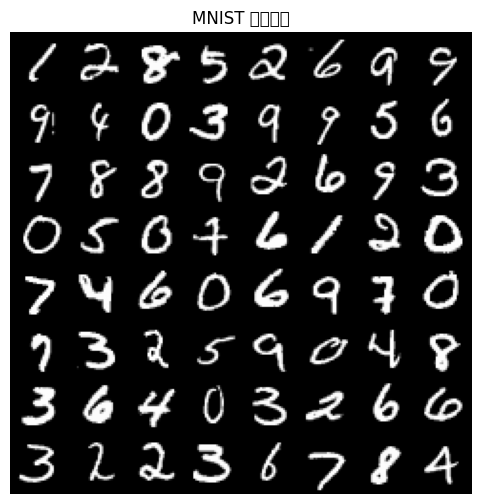

In [3]:
images, labels = next(iter(trainloader))
grid = make_grid(images[:64], nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title("MNIST 训练样本")
plt.axis("off")
plt.show()

## 3. DCGAN 模型定义

根据任务书：

- 判别器采用 `Conv2d + BatchNorm2d + LeakyReLU`，最后一层 `sigmoid`；
- 生成器采用 `ConvTranspose2d + BatchNorm2d + ReLU`，最后一层 `tanh`；
- 整体结构关于特征尺度近似对称。

MNIST 为单通道图像，因此 `n_channel=1`。

In [4]:
class DCGAN_Discriminator(nn.Module):
    def __init__(self, n_channel: int = 1):
        super().__init__()
        self.conv1 = nn.Conv2d(n_channel, 32, 3, stride=2, padding=2, bias=False)
        self.BN1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=0, bias=False)
        self.BN2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, stride=2, padding=0, bias=False)
        self.BN3 = nn.BatchNorm2d(128)
        self.fc = nn.Conv2d(128, 1, 3, 1, 0, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.leaky_relu(self.BN1(self.conv1(x)), negative_slope=0.2, inplace=True)
        x = F.leaky_relu(self.BN2(self.conv2(x)), negative_slope=0.2, inplace=True)
        x = F.leaky_relu(self.BN3(self.conv3(x)), negative_slope=0.2, inplace=True)
        x = torch.sigmoid(self.fc(x))
        x = x.view(x.size(0), -1)
        return x


class DCGAN_Generator(nn.Module):
    def __init__(self, n_channel: int = 1, noise_dim: int = 100):
        super().__init__()
        self.conv1 = nn.ConvTranspose2d(noise_dim, 128, 3, stride=1, padding=0, bias=False)
        self.BN1 = nn.BatchNorm2d(128)
        self.conv2 = nn.ConvTranspose2d(128, 64, 3, stride=2, padding=0, bias=False)
        self.BN2 = nn.BatchNorm2d(64)
        self.conv3 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=0, bias=False)
        self.BN3 = nn.BatchNorm2d(32)
        self.conv4 = nn.ConvTranspose2d(32, n_channel, 3, stride=2, padding=2, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.BN1(self.conv1(x)), inplace=True)
        x = F.relu(self.BN2(self.conv2(x)), inplace=True)
        x = F.relu(self.BN3(self.conv3(x)), inplace=True)
        x = torch.tanh(self.conv4(x))
        return x

In [5]:
NOISE_DIM = 100


def gen_noise(n_instance: int, n_dim: int = 100, device: Optional[torch.device] = None) -> torch.Tensor:
    if device is None:
        device = torch.device("cpu")
    return torch.randn(n_instance, n_dim, 1, 1, device=device)


def init_weights(module: nn.Module) -> None:
    classname = module.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0)


D_demo = DCGAN_Discriminator().to(device)
G_demo = DCGAN_Generator(noise_dim=NOISE_DIM).to(device)
D_demo.apply(init_weights)
G_demo.apply(init_weights)

demo_noise = gen_noise(4, NOISE_DIM, device)
demo_fake = G_demo(demo_noise)
demo_score = D_demo(demo_fake)
print("fake image shape:", tuple(demo_fake.shape))
print("disc output shape:", tuple(demo_score.shape))

fake image shape: (4, 1, 27, 27)
disc output shape: (4, 1)


## 4. 训练函数

训练逻辑保持与任务书一致：

- 判别器同时看真实样本和生成样本；
- 真实标签记为 1，生成标签记为 0；
- 生成器的目标是“骗过”判别器，因此希望生成样本被判为 1；
- 使用 `BCELoss` 和 `Adam(betas=(0.5, 0.999))`。

同时记录每个 epoch 的平均损失，并定期保存固定噪声下的生成结果，便于观察模型从噪声到数字轮廓逐步成形的过程。

In [6]:
@torch.no_grad()
def sample_grid(generator: nn.Module, fixed_noise: torch.Tensor, nrow: int = 8):
    was_training = generator.training
    generator.eval()
    fake = generator(fixed_noise).detach().cpu()
    grid = make_grid(fake, nrow=nrow, normalize=True, value_range=(-1, 1))
    if was_training:
        generator.train()
    return fake, grid


def train_DCGAN(
    Dis_model: nn.Module,
    Gen_model: nn.Module,
    D_criterion: nn.Module,
    G_criterion: nn.Module,
    D_optimizer: optim.Optimizer,
    G_optimizer: optim.Optimizer,
    trainloader,
    n_epoch: int,
    batch_size: int,
    noise_dim: int,
    n_update_dis: int = 1,
    n_update_gen: int = 1,
    print_every: int = 100,
    update_max: Optional[int] = None,
    device: torch.device = torch.device("cpu"),
):
    history: Dict[str, List[float]] = {"D_loss": [], "G_loss": []}
    snapshots: List[torch.Tensor] = []
    fixed_noise = gen_noise(64, noise_dim, device=device)

    for epoch in range(n_epoch):
        Dis_model.train()
        Gen_model.train()
        D_running_loss = 0.0
        G_running_loss = 0.0
        D_epoch_loss = 0.0
        G_epoch_loss = 0.0
        step_count = 0

        for i, data in enumerate(trainloader, 0):
            true_inputs, _ = data
            true_inputs = true_inputs.to(device)

            noises = gen_noise(batch_size, n_dim=noise_dim, device=device)
            fake_inputs = Gen_model(noises)
            inputs = torch.cat([true_inputs, fake_inputs], dim=0)

            labels = torch.zeros(2 * batch_size, device=device)
            labels[:batch_size] = 1.0

            D_optimizer.zero_grad()
            outputs = Dis_model(inputs)
            D_loss = D_criterion(outputs[:, 0], labels)

            if i % n_update_dis == 0:
                D_loss.backward(retain_graph=True)
                D_optimizer.step()

            if i % n_update_gen == 0:
                G_optimizer.zero_grad()
                gen_targets = torch.ones(batch_size, device=device)
                G_outputs = Dis_model(fake_inputs)
                G_loss = G_criterion(G_outputs[:, 0], gen_targets)
                G_loss.backward()
                G_optimizer.step()
            else:
                G_loss = torch.tensor(0.0, device=device)

            D_running_loss += D_loss.item()
            G_running_loss += G_loss.item()
            D_epoch_loss += D_loss.item()
            G_epoch_loss += G_loss.item()
            step_count += 1

            if (i + 1) % print_every == 0:
                print(
                    f"[epoch {epoch + 1:02d}, step {i + 1:04d}] "
                    f"D loss: {D_running_loss / print_every:.4f} ; "
                    f"G loss: {G_running_loss / print_every:.4f}"
                )
                D_running_loss = 0.0
                G_running_loss = 0.0

            if update_max is not None and (i + 1) >= update_max:
                break

        history["D_loss"].append(D_epoch_loss / max(step_count, 1))
        history["G_loss"].append(G_epoch_loss / max(step_count, 1))
        _, grid = sample_grid(Gen_model, fixed_noise, nrow=8)
        snapshots.append(grid)
        print(
            f"epoch {epoch + 1:02d}/{n_epoch:02d} finished | "
            f"D loss={history['D_loss'][-1]:.4f}, G loss={history['G_loss'][-1]:.4f}"
        )

    print("Finished Training")
    return history, snapshots, fixed_noise

## 5. 运行主实验

任务书推荐参数：

- `n_epoch=50`
- `batch_size=100`
- `dis_lr=4e-4`
- `gen_lr=4e-4`
- `noise_dim=100`
- 判别器与生成器更新频率均为 1

若你只是先验证流程能否跑通，可把 `N_EPOCH` 改小，或设置 `UPDATE_MAX` 为较小整数。

In [7]:
def run_DCGAN(
    n_epoch: int = 10,
    batch_size: int = 100,
    dis_lr: float = 4e-4,
    gen_lr: float = 4e-4,
    n_update_dis: int = 1,
    n_update_gen: int = 1,
    noise_dim: int = 100,
    n_channel: int = 1,
    download: bool = True,
    update_max: Optional[int] = None,
    device: torch.device = torch.device("cpu"),
):
    trainloader, testloader = load_dataset(batch_size=batch_size, download=download)

    Dis_model = DCGAN_Discriminator(n_channel=n_channel).to(device)
    Gen_model = DCGAN_Generator(n_channel=n_channel, noise_dim=noise_dim).to(device)
    Dis_model.apply(init_weights)
    Gen_model.apply(init_weights)

    D_criterion = torch.nn.BCELoss()
    G_criterion = torch.nn.BCELoss()
    D_optimizer = optim.Adam(Dis_model.parameters(), lr=dis_lr, betas=(0.5, 0.999))
    G_optimizer = optim.Adam(Gen_model.parameters(), lr=gen_lr, betas=(0.5, 0.999))

    history, snapshots, fixed_noise = train_DCGAN(
        Dis_model,
        Gen_model,
        D_criterion,
        G_criterion,
        D_optimizer,
        G_optimizer,
        trainloader,
        n_epoch=n_epoch,
        batch_size=batch_size,
        noise_dim=noise_dim,
        n_update_dis=n_update_dis,
        n_update_gen=n_update_gen,
        print_every=100,
        update_max=update_max,
        device=device,
    )

    return {
        "D": Dis_model,
        "G": Gen_model,
        "trainloader": trainloader,
        "testloader": testloader,
        "history": history,
        "snapshots": snapshots,
        "fixed_noise": fixed_noise,
    }


N_EPOCH = 10
UPDATE_MAX = None  # 想快速试跑可设为 200 或 300

dcgan_result = run_DCGAN(
    n_epoch=N_EPOCH,
    batch_size=BATCH_SIZE,
    dis_lr=4e-4,
    gen_lr=4e-4,
    noise_dim=NOISE_DIM,
    update_max=UPDATE_MAX,
    download=True,
    device=device,
)

RuntimeError: Sizes of tensors must match except in dimension 0. Expected size 28 but got size 27 for tensor number 1 in the list.

## 6. 损失曲线与生成结果

通常训练早期会看到：

- 判别器损失先快速下降；
- 生成器损失在震荡中逐步下降；
- 生成样本从模糊噪声逐渐出现笔画和数字轮廓。

GAN 的损失曲线往往不如分类任务那样单调，因此应结合生成图片一起分析。

In [ ]:
history = dcgan_result["history"]
plt.figure(figsize=(8, 4))
plt.plot(history["D_loss"], label="Discriminator loss")
plt.plot(history["G_loss"], label="Generator loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("DCGAN 训练损失曲线")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
snapshots = dcgan_result["snapshots"]
show_ids = [0, max(len(snapshots) // 2, 0), len(snapshots) - 1]
show_ids = sorted(set([i for i in show_ids if i >= 0]))
plt.figure(figsize=(12, 4))
for plot_idx, snap_idx in enumerate(show_ids, start=1):
    plt.subplot(1, len(show_ids), plot_idx)
    plt.imshow(snapshots[snap_idx].permute(1, 2, 0).squeeze(), cmap="gray")
    plt.title(f"epoch {snap_idx + 1}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
G_model = dcgan_result["G"]
fixed_noise = dcgan_result["fixed_noise"]
_, final_grid = sample_grid(G_model, fixed_noise, nrow=8)
plt.figure(figsize=(6, 6))
plt.imshow(final_grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title("最终生成结果")
plt.axis("off")
plt.show()

## 7. 扩展实验：BIGGAN 原理分析与对比思路

任务书要求进一步分析 `BIGGAN` 并与 `DCGAN` 对比。第一版先给出报告中可直接使用的分析框架：

1. `DCGAN` 更适合入门级生成实验，结构相对简单，通常用于较低分辨率图像；
2. `BIGGAN` 在类别条件建模、模型规模、训练稳定性和生成质量上都更强，适合复杂自然图像；
3. `DCGAN` 可在 MNIST 等小型数据集上较快训练，`BIGGAN` 往往依赖更大数据集和更强算力；
4. 对比时可从图像清晰度、多样性、训练成本、收敛难度四个方面展开。

如果后续你要把扩展实验真正跑起来，建议：

- `DCGAN`：换成你感兴趣的单类或多类图像数据集；
- `BIGGAN`：先做**预训练模型推理**理解输入输出，再尝试迁移到自定义数据。

In [ ]:
# 可选：BIGGAN 预训练推理示例（默认不强制运行）
# 需要先安装: pip install pytorch-pretrained-biggan

try:
    from pytorch_pretrained_biggan import BigGAN, one_hot_from_names, truncated_noise_sample
    BIGGAN_AVAILABLE = True
except Exception as exc:
    BIGGAN_AVAILABLE = False
    print("BIGGAN 依赖未安装，跳过该部分：", exc)


def run_biggan_demo(class_name: str = "golden retriever", truncation: float = 0.4, batch_size: int = 4):
    if not BIGGAN_AVAILABLE:
        raise RuntimeError("请先安装 pytorch-pretrained-biggan")

    model = BigGAN.from_pretrained("biggan-deep-128")
    model.to(device)
    model.eval()

    class_vector = one_hot_from_names([class_name] * batch_size, batch_size=batch_size)
    noise_vector = truncated_noise_sample(truncation=truncation, batch_size=batch_size)
    noise_vector = torch.from_numpy(noise_vector).to(device)
    class_vector = torch.from_numpy(class_vector).to(device)

    with torch.no_grad():
        output = model(noise_vector, class_vector, truncation)

    output = output.detach().cpu()
    grid = make_grid(output, nrow=2, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(f"BIGGAN demo: {class_name}")
    plt.axis("off")
    plt.show()


# 取消注释以测试 BIGGAN 预训练结果
# run_biggan_demo()

## 8. 保存实验数据与图片

完成训练后运行本节，会把损失、最终样本图和若干中间结果写入 `experiment_outputs/dcgan_mnist/`，便于后续写报告。

In [ ]:
import json

EXP_DIR = Path("experiment_outputs") / "dcgan_mnist"
EXP_DIR.mkdir(parents=True, exist_ok=True)

np.savez(
    EXP_DIR / "history.npz",
    D_loss=np.array(dcgan_result["history"]["D_loss"], dtype=np.float32),
    G_loss=np.array(dcgan_result["history"]["G_loss"], dtype=np.float32),
)

plt.figure(figsize=(6, 6))
plt.imshow(final_grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.savefig(EXP_DIR / "generated_final.png", dpi=160, bbox_inches="tight")
plt.close()

for idx, snap in enumerate(dcgan_result["snapshots"], start=1):
    plt.figure(figsize=(6, 6))
    plt.imshow(snap.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(EXP_DIR / f"snapshot_epoch_{idx:03d}.png", dpi=160, bbox_inches="tight")
    plt.close()

summary = {
    "epochs": N_EPOCH,
    "batch_size": BATCH_SIZE,
    "noise_dim": NOISE_DIM,
    "device": str(device),
    "final_D_loss": float(dcgan_result["history"]["D_loss"][-1]),
    "final_G_loss": float(dcgan_result["history"]["G_loss"][-1]),
}
(EXP_DIR / "summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved to", EXP_DIR.resolve())

## 9. 实验报告撰写提示

可按以下思路整理实验报告：

1. **实验目的**：掌握 GAN / DCGAN 的基本思想，理解生成器和判别器的对抗训练机制；
2. **实验环境**：Python、PyTorch、GPU/CPU 配置；
3. **实验原理**：说明 GAN、DCGAN、卷积替代池化、BN、`ReLU/LeakyReLU/Tanh` 的作用；
4. **实验过程**：数据加载、模型结构、损失函数、优化器、超参数设置；
5. **实验结果**：展示损失曲线和若干 epoch 的生成图片；
6. **结果分析**：分析生成质量变化、训练稳定性、模式崩溃风险；
7. **扩展实验**：从结构复杂度、生成质量、算力需求等角度比较 `DCGAN` 与 `BIGGAN`。